In [150]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score, f1_score

In [54]:
df = pd.read_csv('dataset.csv')

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [55]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,9324.000000,9324.000000,9324.000000,9324.000000,9324.000000,9324.000000,9324.000000
mean,55.885993,52.454848,43.725547,26.496638,72.413670,6.578284,103.283951
std,37.190518,29.925679,42.965660,5.352988,22.916171,0.793327,56.163347
min,0.000000,4.000000,5.000000,8.825675,14.258040,3.504752,5.314507
25%,25.000000,29.000000,21.000000,23.338494,60.445305,6.078439,63.835498
50%,43.000000,51.000000,32.000000,26.600190,81.017834,6.542777,93.172220
75%,90.000000,68.000000,48.000000,29.502934,90.297518,7.033908,130.379712
max,149.000000,150.000000,206.000000,46.732778,104.980970,10.233143,298.560117


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9324 entries, 0 to 9323
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            9324 non-null   int64  
 1   P            9324 non-null   int64  
 2   K            9324 non-null   int64  
 3   temperature  9324 non-null   float64
 4   humidity     9324 non-null   float64
 5   ph           9324 non-null   float64
 6   rainfall     9324 non-null   float64
 7   label        9324 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 582.9+ KB


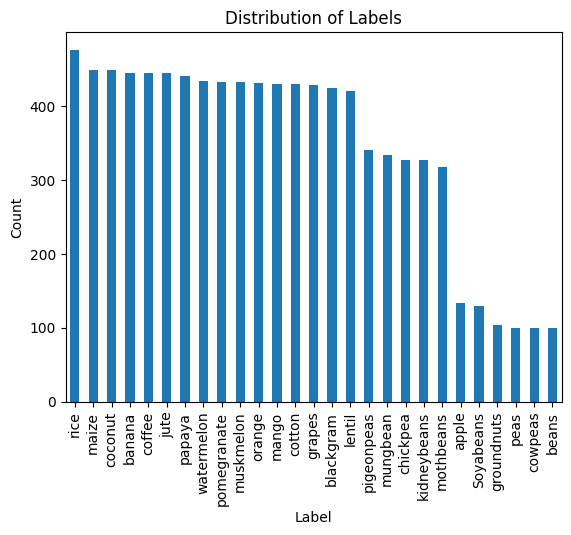

In [60]:
df["label"].value_counts().plot(kind="bar")
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Distribution of Labels")
plt.show()

In [88]:
total_labels = df["label"].nunique()
print(f"Total unique labels: {total_labels}")

Total unique labels: 27


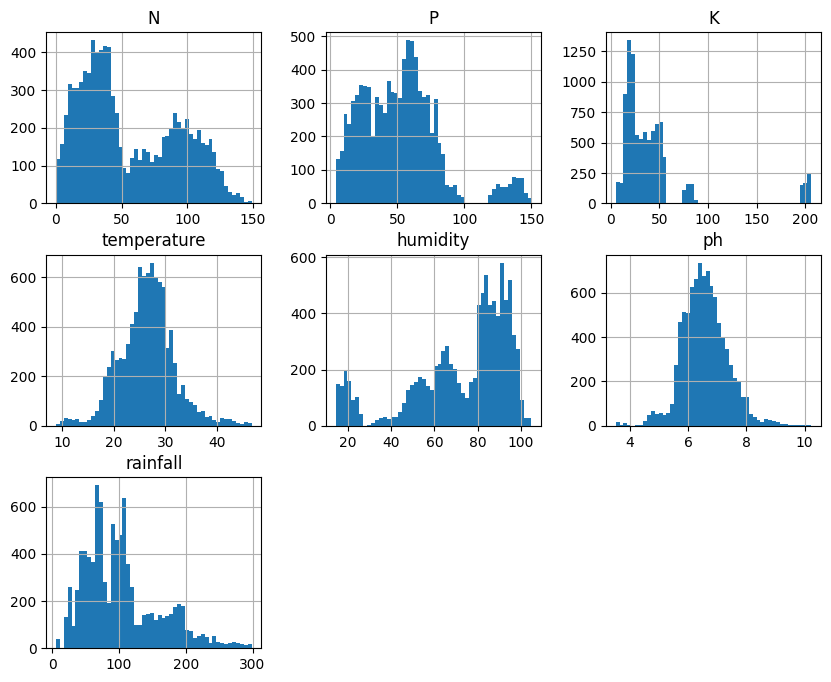

In [57]:
df.hist(bins=50, figsize=(10,8))
plt.show()

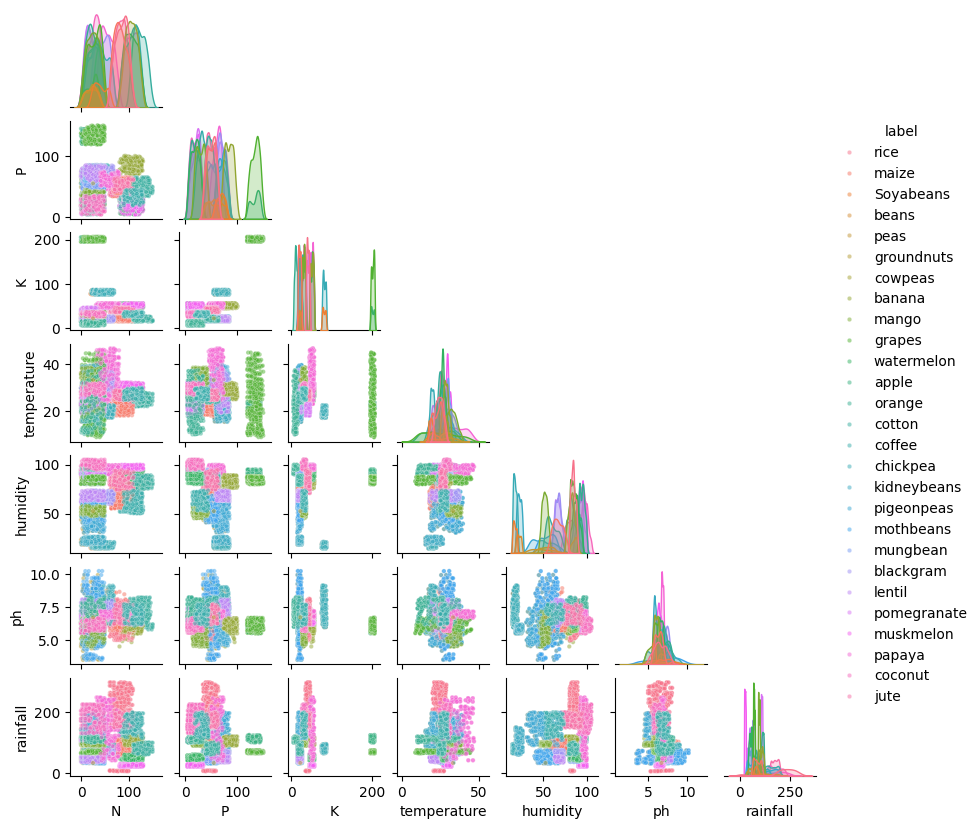

In [58]:
sns.pairplot(
    df,
    hue="label",
    corner=True,
    height=1.2,
    plot_kws={'s': 10, 'alpha': 0.5},   # smaller points
)

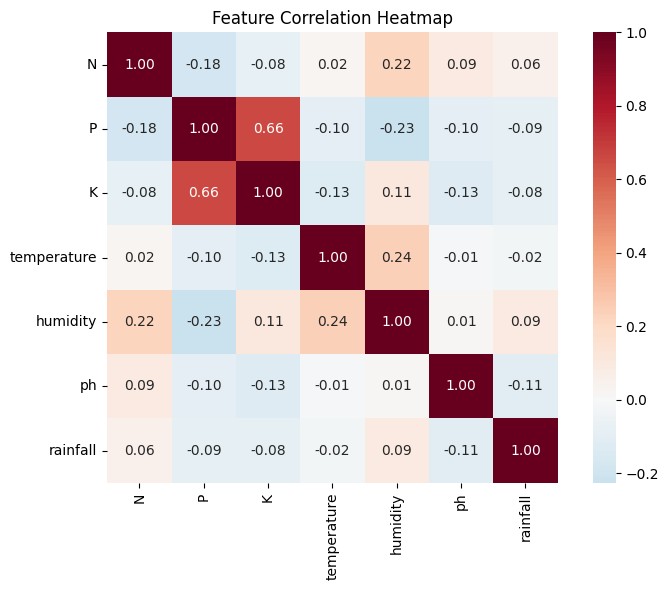

In [59]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [65]:
le = LabelEncoder()
df["label"] = le.fit_transform(df["label"])

In [69]:
X = df.drop("label", axis=1)
y = df["label"]

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

In [111]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Logistic Regression

In [153]:
logreg_clf = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000))
])

param_grid = {
    'poly__degree': [1, 2],
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['saga']
}

grid_search = GridSearchCV(
    estimator=logreg_clf,
    param_grid=param_grid,
    cv=cv,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1
)

In [154]:
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\Nizwa\miniconda3\envs\ai\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Nizwa\miniconda3\envs\ai\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Best Hyperparameters: {'classifier__C': 10, 'classifier__penalty': 'l1', 'classifier__solver': 'saga', 'poly__degree': 2}
Best CV Accuracy: 0.8516804540459662


c:\Users\Nizwa\miniconda3\envs\ai\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [155]:
best_logreg = grid_search.best_estimator_

y_pred = best_logreg.predict(X_test)

balanced_acc = balanced_accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print("Balanced Accuracy:", balanced_acc)
print("Weighted F1 Score:", f1)

Balanced Accuracy: 0.8486918059585413
Weighted F1 Score: 0.9058700501233078


## K Nearest Neighbors

In [123]:
knn_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier())
])

param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 9],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan', 'minkowski'],
    'classifier__p': [1, 2]
}

grid_search = GridSearchCV(
    estimator=knn_clf,
    param_grid=param_grid,
    cv=cv,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1
)

In [124]:
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Hyperparameters: {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 9, 'classifier__p': 1, 'classifier__weights': 'uniform'}
Best CV Accuracy: 0.8055190317932052


In [125]:
best_knn = grid_search.best_estimator_

y_pred = best_knn.predict(X_test)

balanced_acc = balanced_accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print("Balanced Accuracy:", balanced_acc)
print("Weighted F1 Score:", f1)

Balanced Accuracy: 0.8075299248332368
Weighted F1 Score: 0.9105619143605475


## Decision Tree

In [126]:
dt_clf = DecisionTreeClassifier(random_state=42, class_weight='balanced')

param_grid = {
    'max_depth': [3, 5, 7, 9],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=dt_clf,
    param_grid=param_grid,
    cv=cv,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1
)

In [127]:
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Hyperparameters: {'max_depth': 9, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV Accuracy: 0.8617655986950377


In [ ]:
best_dt = grid_search.best_estimator_

y_pred = best_dt.predict(X_test)

balanced_acc = balanced_accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print("Balanced Accuracy:", balanced_acc)
print("Weighted F1 Score:", f1)

Balanced Accuracy: 0.8716119736155945
Weighted F1 Score: 0.8909784819629398


## Best Baseline Metric

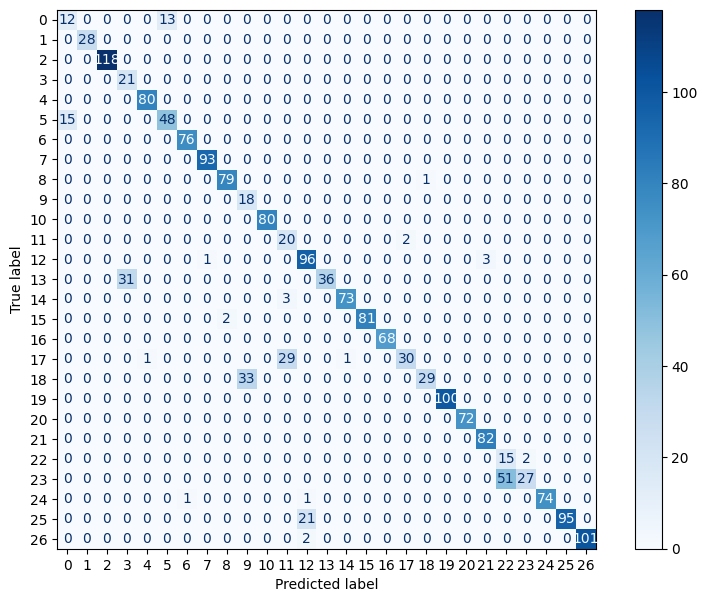

In [135]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_dt.classes_)
disp.plot(ax=ax, cmap="Blues", colorbar=True)
plt.show()

In [136]:
report = classification_report(y_test, y_pred, output_dict=True)

df_report = pd.DataFrame(report).transpose()
df_report.head(total_labels + 4)

,precision,recall,f1-score,support
0,0.444444,0.480000,0.461538,25.000000
1,1.000000,1.000000,1.000000,28.000000
2,1.000000,1.000000,1.000000,118.000000
3,0.403846,1.000000,0.575342,21.000000
4,0.987654,1.000000,0.993789,80.000000
5,0.786885,0.761905,0.774194,63.000000
6,0.987013,1.000000,0.993464,76.000000
7,0.989362,1.000000,0.994652,93.000000
8,0.975309,0.987500,0.981366,80.000000
9,0.352941,1.000000,0.521739,18.000000


# Ensemble Methods

## Random Forest

In [146]:
rf_clf = RandomForestClassifier(random_state=42, class_weight='balanced')

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['log2', 'sqrt']
}

grid_search = GridSearchCV(
    estimator=rf_clf,
    param_grid=param_grid,
    cv=cv,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1
)

In [147]:
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best Hyperparameters: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}
Best CV Accuracy: 0.8575040920756685


In [149]:
best_dt = grid_search.best_estimator_

y_pred = best_dt.predict(X_test)

balanced_acc = balanced_accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print("Balanced Accuracy:", balanced_acc)
print("Weighted F1 Score:", f1)

Balanced Accuracy: 0.8479993013054565
Weighted F1 Score: 0.9112461361720694
